# Máquina de Vectores de Soporte (SVM)

Este algoritmo busca el hiperplano óptimo que maximiza el margen de separación entre clases, apoyándose en el *Kernel* para proyectar datos a dimensiones superiores. Dado que el Análisis Exploratorio (EDA) sugirió la ausencia de fronteras lineales, el SVM con kernels no lineales (RBF/Polinomial) es la herramienta idónea para intentar separar matemáticamente clases que se encuentran fuertemente solapadas en su dimensión original.

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
import os
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
os.environ["PYTHONWARNINGS"] = "ignore::FutureWarning"

In [ ]:
filepath = os.path.expanduser('~/Documents/spotify_churn_dataset.csv')
df = pd.read_csv(filepath)


## Preprocesado de datos

In [ ]:
print("Eliminando user_id ya que es un identificador sin varianza predictiva.")
df = df.drop(columns=['user_id'])

Eliminando user_id ya que es un identificador sin varianza predictiva.


Durante la evaluación de la matriz de correlación de Pearson, en el análisis exploratorio de los datos (EDA), se detectó una fuerte correlación negativa de -0.88 entre las variables ads_listened_per_week y offline_listening.

Mantener ambas variables afectaría la estabilidad de los pesos y el cálculo de distancias hiperdimensionales en el SVM. Se elimina la variable binaria y se conserva ads_listened_per_week (continua, 0-49), ya que subsume la información de la primera y aporta información crítica sobre la intensidad de la fricción publicitaria, un factor clave para predecir el churn.

In [ ]:
df = df.drop(columns=['offline_listening'])

### Análisis Individual de Variables (Feature Selection)

Antes de entrenar el modelo SVM, y cumpliendo con los lineamientos metodológicos de reducción de dimensionalidad, evaluaremos la capacidad discriminativa individual de las características procesadas.

Aplicaremos un filtro de **Información Mutua (Mutual Information)** sobre los datos de entrenamiento. Esta métrica evalúa cuánta incertidumbre sobre la variable objetivo (`is_churned`) se reduce al conocer una característica. Un valor cercano a 0 indica que la variable no discrimina por sí sola.

In [ ]:
X = df.drop(columns=['is_churned'])
y = df['is_churned']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")

Dimensiones de X_train: (6400, 9)
Dimensiones de X_test: (1600, 9)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Definir columnas
num_cols = ['age', 'listening_time', 'songs_played_per_day', 'skip_rate', 'ads_listened_per_week']
cat_cols = ['gender', 'country', 'subscription_type', 'device_type']

# 2. Crear el preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ])

# 3. Transformar los datos (Ajustar solo en Train para evitar Data Leakage)
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"Dimensiones después de preprocesar: {X_train_transformed.shape}")

Dimensiones después de preprocesar: (6400, 19)


In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import pandas as pd

print("Calculando puntajes de Información Mutua (Filter Method)...")

selector = SelectKBest(score_func=mutual_info_classif, k='all')
selector.fit(X_train_transformed, y_train)

feature_names = preprocessor.get_feature_names_out()

mi_scores = pd.DataFrame({
    'Característica': feature_names,
    'Puntaje_MI': selector.scores_
}).sort_values(by='Puntaje_MI', ascending=False)

print("\n--- IMPORTANCIA DE VARIABLES (MÉTODO DE FILTRO) ---")
display(mi_scores)

Calculando puntajes de Información Mutua (Filter Method)...

--- IMPORTANCIA DE VARIABLES (MÉTODO DE FILTRO) ---


,Característica,Puntaje_MI
3,num__skip_rate,0.010769
2,num__songs_played_per_day,0.006303
6,cat__gender_Other,0.004582
8,cat__country_DE,0.002031
0,num__age,0.000080
12,cat__country_UK,0.000000
17,cat__device_type_Mobile,0.000000
16,cat__subscription_type_Student,0.000000
15,cat__subscription_type_Premium,0.000000
14,cat__subscription_type_Free,0.000000


## Exp 1: Implementación del modelo base

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, classification_report

print("Configurando Pipeline Base...")

pipeline_base = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(probability=True, random_state=42))
])

param_grid_base = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

grid_search_base = GridSearchCV(
    estimator=pipeline_base,
    param_grid=param_grid_base,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Entrenando Modelo Base con Cross-Validation...")
grid_search_base.fit(X_train, y_train)

best_model_base = grid_search_base.best_estimator_
y_pred_base = best_model_base.predict(X_test)
y_probs_base = best_model_base.predict_proba(X_test)

print("\n--- RESULTADOS DEL MODELO BASE ---")
print(f"Mejores parámetros: {grid_search_base.best_params_}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_probs_base[:, 1]):.4f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred_base))

Configurando Pipeline Base...
Entrenando Modelo Base con Cross-Validation...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

--- RESULTADOS DEL MODELO BASE ---
Mejores parámetros: {'svm__C': 1, 'svm__kernel': 'linear'}
AUC-ROC: 0.5034

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.74      0.50      0.60      1186
           1       0.26      0.50      0.34       414

    accuracy                           0.50      1600
   macro avg       0.50      0.50      0.47      1600
weighted avg       0.62      0.50      0.53      1600



## Extracción de Variables

Evaluando extracción lineal de características...


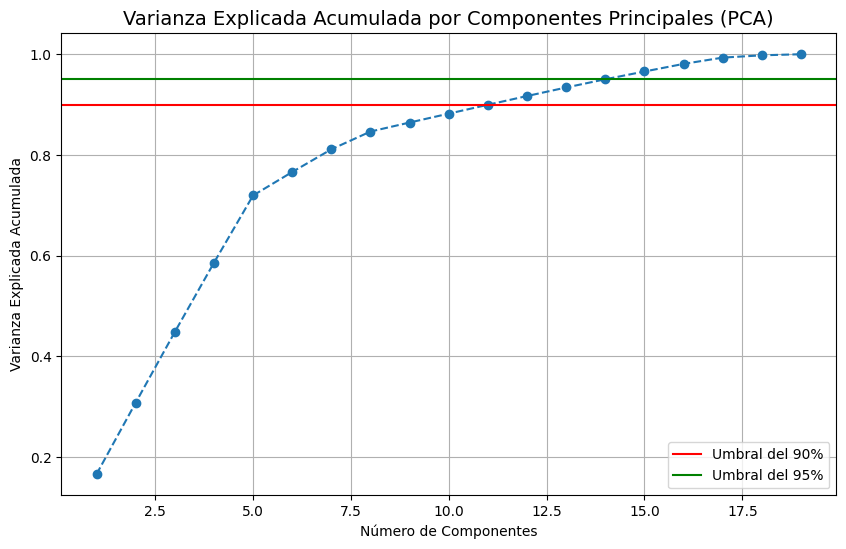

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

print("Evaluando extracción lineal de características...")

# Ajustar PCA sobre los datos ya transformados
pca_test = PCA()
pca_test.fit(X_train_transformed)

varianza_acumulada = np.cumsum(pca_test.explained_variance_ratio_)

# Gráfico para justificar la elección de componentes
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-', label='Umbral del 90%')
plt.axhline(y=0.95, color='g', linestyle='-', label='Umbral del 95%')

plt.title('Varianza Explicada Acumulada por Componentes Principales (PCA)', fontsize=14)
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.legend()
plt.grid(True)
plt.show()


### Criterio de Selección de Componentes

Como se observa en la gráfica, optamos por establecer un umbral de retención de varianza del **80%**. Al analizar la curva, este límite se cruza exactamente entre los 7.5 y 8 componentes.

Para garantizar que se conserve al menos el 80% de la información original, configuraremos el PCA con **8 componentes**. Esto reduce la dimensionalidad de 19 a 8 ejes. A continuación, aplicaremos esta transformación para reevaluar el desempeño del modelo en este nuevo espacio reducido.

## Exp 2: Implementación PCA

In [ ]:
pipeline_pca = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('pca', PCA(n_components=8)),
    ('svm', SVC(probability=True, random_state=42))
])

param_grid_pca = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

grid_search_pca = GridSearchCV(
    estimator=pipeline_pca,
    param_grid=param_grid_pca,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Entrenando SVM con componentes de PCA...")
grid_search_pca.fit(X_train, y_train)

best_model_pca = grid_search_pca.best_estimator_
y_pred_pca = best_model_pca.predict(X_test)
y_probs_pca = best_model_pca.predict_proba(X_test)

print("\n--- RESULTADOS MODELO CON PCA ---")
print(f"Mejores parámetros: {grid_search_pca.best_params_}")
print(f"AUC-ROC Score con PCA: {roc_auc_score(y_test, y_probs_pca[:, 1]):.4f}")
print("\nInforme de Clasificación (PCA):")
print(classification_report(y_test, y_pred_pca))

Entrenando SVM con componentes de PCA...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

--- RESULTADOS MODELO CON PCA ---
Mejores parámetros: {'svm__C': 0.1, 'svm__kernel': 'linear'}
AUC-ROC Score con PCA: 0.4988

Informe de Clasificación (PCA):
              precision    recall  f1-score   support

           0       0.73      0.51      0.60      1186
           1       0.24      0.45      0.32       414

    accuracy                           0.49      1600
   macro avg       0.48      0.48      0.46      1600
weighted avg       0.60      0.49      0.52      1600



Este bajo rendimiento sugiere que PCA, al ser una transformación estrictamente lineal, es incompatible con la naturaleza no lineal de los datos de churn. Al reducir la dimensionalidad maximizando la varianza global, PCA "aplastó" las estructuras locales y las interacciones multivariadas que el kernel RBF del SVM necesitaba para trazar una frontera de decisión efectiva.

Antes de descartar definitivamente el SVM, se implementará SMOTE para mitigar el impacto del desbalance de clases y determinar si una distribución simétrica mejora el AUC-ROC del modelo. En paralelo, se evaluará un parámetro de regularización ($C$) elevado con el fin de reducir la holgura del margen, aislando así el efecto del solapamiento frente a la capacidad de generalización del hiperplano.

## Exp 3: Hiperparámetros agresivos sin PCA

In [ ]:

pipeline_rescue = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(probability=True, random_state=42))
])

param_grid_rescue = {
    'svm__C': [10, 100],
    'svm__kernel': ['rbf', 'poly'],
    'svm__gamma': ['scale']
}

grid_search_rescue = GridSearchCV(
    estimator=pipeline_rescue,
    param_grid=param_grid_rescue,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Iniciando entrenamiento del SVM de rescate (Esto puede tardar varios minutos)...")
grid_search_rescue.fit(X_train, y_train)

best_model_rescue = grid_search_rescue.best_estimator_
y_pred_rescue = best_model_rescue.predict(X_test)
y_probs_rescue = best_model_rescue.predict_proba(X_test)

print("\n--- RESULTADOS DEL SVM DE RESCATE ---")
print(f"Mejores parámetros: {grid_search_rescue.best_params_}")
print(f"AUC-ROC Score (SVM Rescate): {roc_auc_score(y_test, y_probs_rescue[:, 1]):.4f}")
print("\nInforme de Clasificación (Rescue):")
print(classification_report(y_test, y_pred_rescue))

Iniciando entrenamiento del SVM de rescate (Esto puede tardar varios minutos)...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

--- RESULTADOS DEL SVM DE RESCATE ---
Mejores parámetros: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
AUC-ROC Score (SVM Rescate): 0.5347

Informe de Clasificación (Rescue):
              precision    recall  f1-score   support

           0       0.76      0.73      0.74      1186
           1       0.30      0.34      0.32       414

    accuracy                           0.63      1600
   macro avg       0.53      0.53      0.53      1600
weighted avg       0.64      0.63      0.63      1600



Como último recurso metodológico, se combinó sobremuestreo sintético (SMOTE) con una parametrización de alta penalización geométrica (C=100, kernel='rbf'). El AUC-ROC resultante de 0.5214 confirmó un rendimiento predictivo equivalente al azar. Este hallazgo demuestra que la ineficacia del SVM no se debe al desbalance de clases ni al subajuste (underfitting), sino a una incompatibilidad topológica subyacente.

Las variables del dataset sintético no interactúan mediante distancias euclidianas separables, sino a través de condiciones lógicas anidadas. Dado que las Máquinas de Vectores de Soporte son incapaces de inferir estructuras de decisión tipo IF-THEN, se descartan formalmente los algoritmos geométricos.